# **Calidad de Procesos de Fermentación (Vino)**

Integrantes:




Idea Principal: Predecir la puntuación de calidad del vino (clasificación multiclase o regresión ordinal) a partir de pruebas fisicoquímicas (pH, sulfatos, alcohol).
Base de Datos: Wine Quality Dataset (UCI).
Modelos: Los equipos pueden tratarlo como regresión o clasificación. Si eligen regresión, el énfasis estará en minimizar el MAE para evitar que un error de predicción de "2 estrellas" afecte cuadráticamente la función de costo, contrastando regularizadores contra un perceptrón multicapa.


In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

seed = 2026
np.random.seed(seed)


## **Análisis exploratorio de datos**

In [88]:
red = pd.read_csv('winequality-red.csv', sep=';')
red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [89]:
white = pd.read_csv('winequality-white.csv', sep=';')
white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


Unimos las dos bases creando una nueva variable "category"



In [90]:
# creamos una columna nueva en cada uno para después poder unirlas
red['category'] = 'red'
white['category'] = 'white'
df = pd.concat([red, white], ignore_index=True)
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,category
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [91]:
# Conviertimos la variable categórica 'category' en numérica.
df = pd.get_dummies(df, columns=['category'], drop_first=True)

In [92]:
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,category_white
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,False
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,False
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,False
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,False
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,False


In [93]:
# Verificamos las dimensiones del DataFrame resultante.
print(df.shape)


(6497, 13)


Tenemos 13 columnas y 6497 filas en el dataset

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  category_white        6497 non-null   bool   
dtypes: bool(1), float64(11), int64(1)
memory usage: 615.6 KB


In [95]:
# Contamos los valores nulos por columna
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [96]:
# Estadísticas descriptivas
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


### Análisis de la variable de salida

In [97]:
quality = df['quality'] # variable objetivo
quality.describe() # estadistícas descriptivas

,quality
count,6497.000000
mean,5.818378
std,0.873255
min,3.000000
25%,5.000000
50%,6.000000
75%,6.000000
max,9.000000


In [98]:
# Para saber cuántos vinos tienen cada puntuación de calidad
quality.value_counts()

,count
quality,
6,2836
5,2138
7,1079
4,216
8,193
3,30
9,5


Podemos obervar que el dataset está desbalanceado:

*   La mayoría de los datos estan centrados en calidad 5 y 6
*   Tenemos muy pocos de calidad 3 y 9


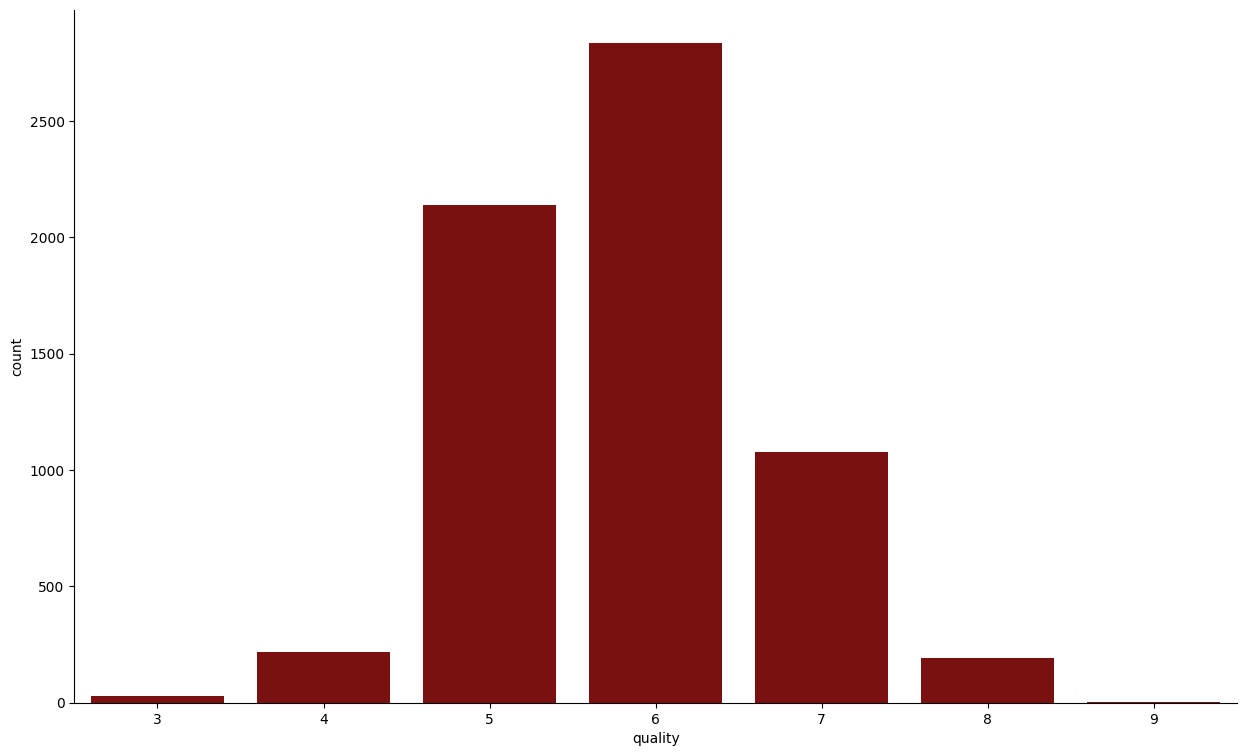

In [99]:
# Gráfica de barras de la distribución de calidad.
plt.figure(figsize=(15,9))
sns.countplot(data=df, x='quality', color='darkred')
sns.despine() # quita bordes de arriba y derecha
plt.show()

### Análisis de las demás variables




In [100]:
# Para el EDA de las variables predictoras eliminamos 'quality'
df1 = df.drop(columns=['quality'])
df1.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,category_white
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,False
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,False
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,False
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,False
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,False




*   Histogramas




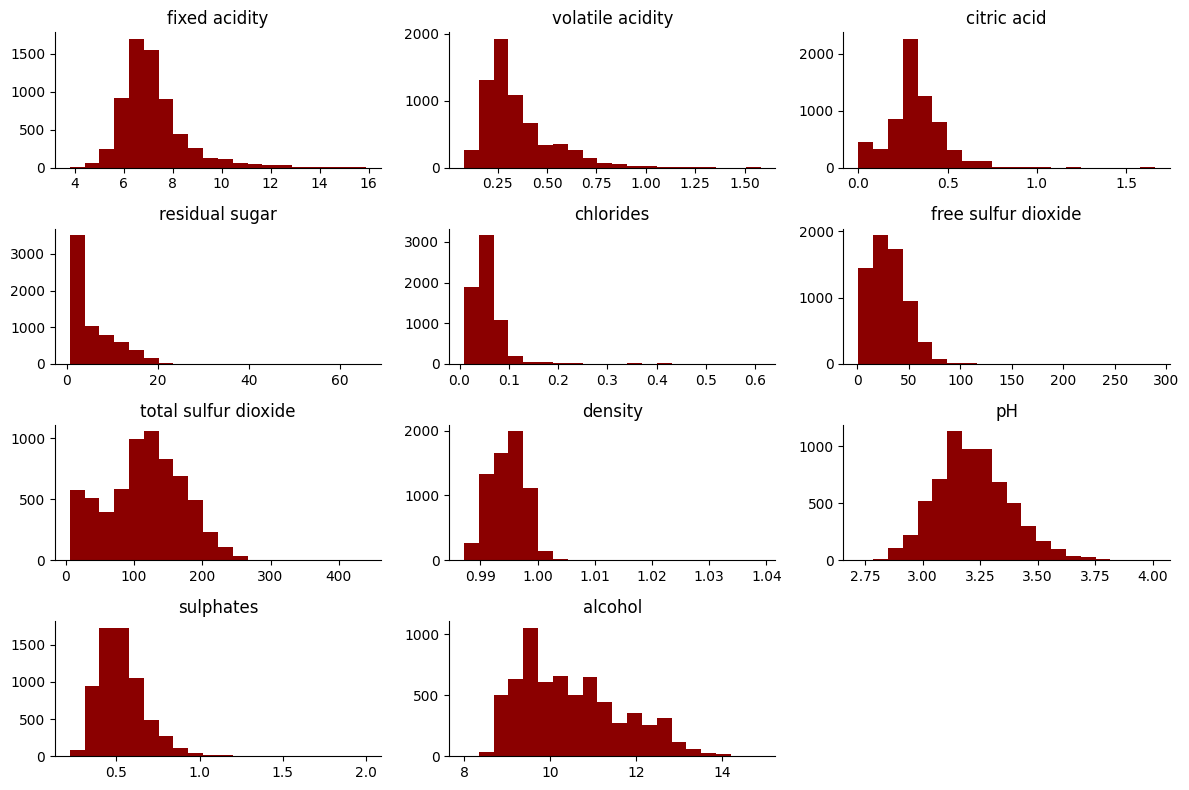

In [101]:
# Histogramas de todas las variables predictoras
axes = df1.hist(bins=20, figsize=(12,8), color='darkred')

for ax in axes.flatten():
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()



*   Box-Plot



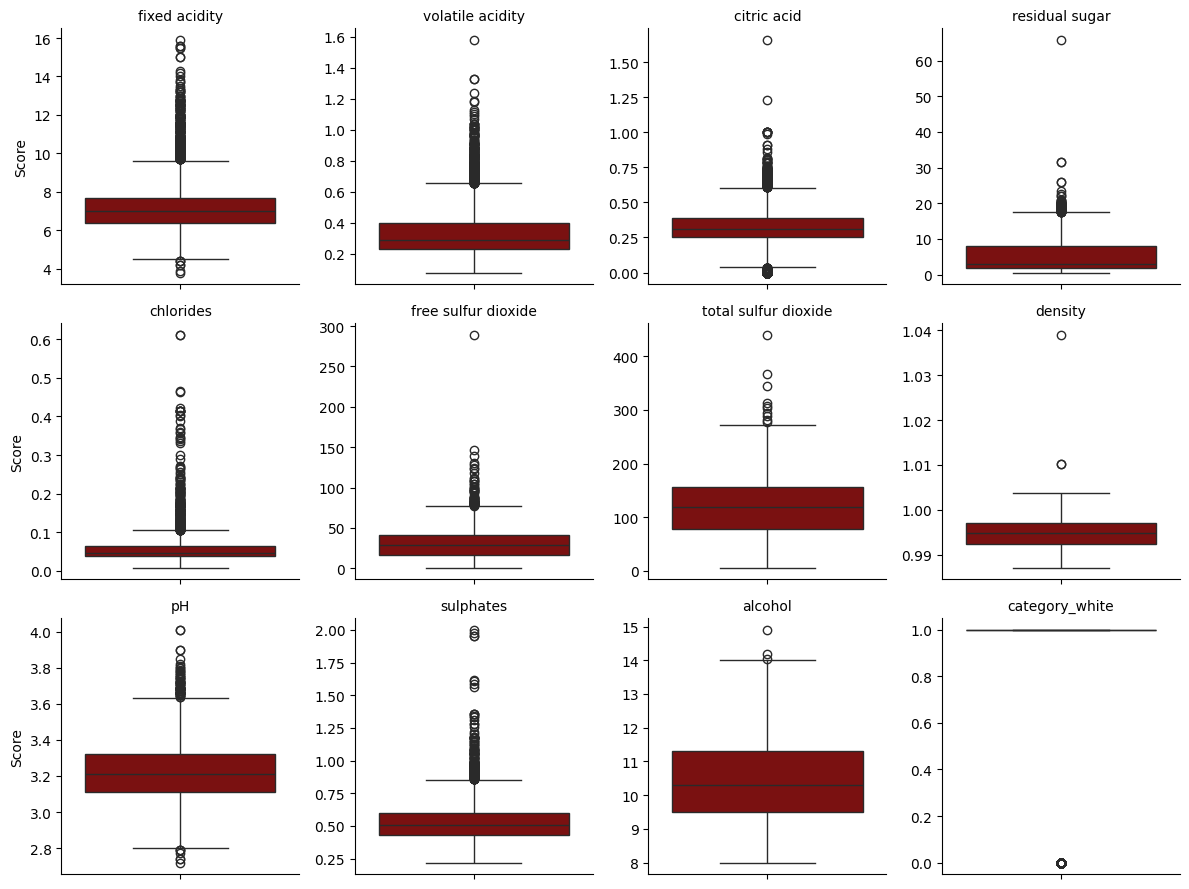

In [102]:
# Para graficar boxplots de cada variable
df_long = df.melt(
    id_vars='quality',
    var_name='Variable',
    value_name='Score')

g = sns.FacetGrid(df_long, col='Variable', col_wrap=4, sharey=False, sharex=False) # las variables tienen escalas muy distintas

g.map_dataframe(
    sns.boxplot,
    y='Score',
    color='darkred')

g.set_titles('{col_name}')
g.fig.tight_layout()

plt.show()



*   Densidad



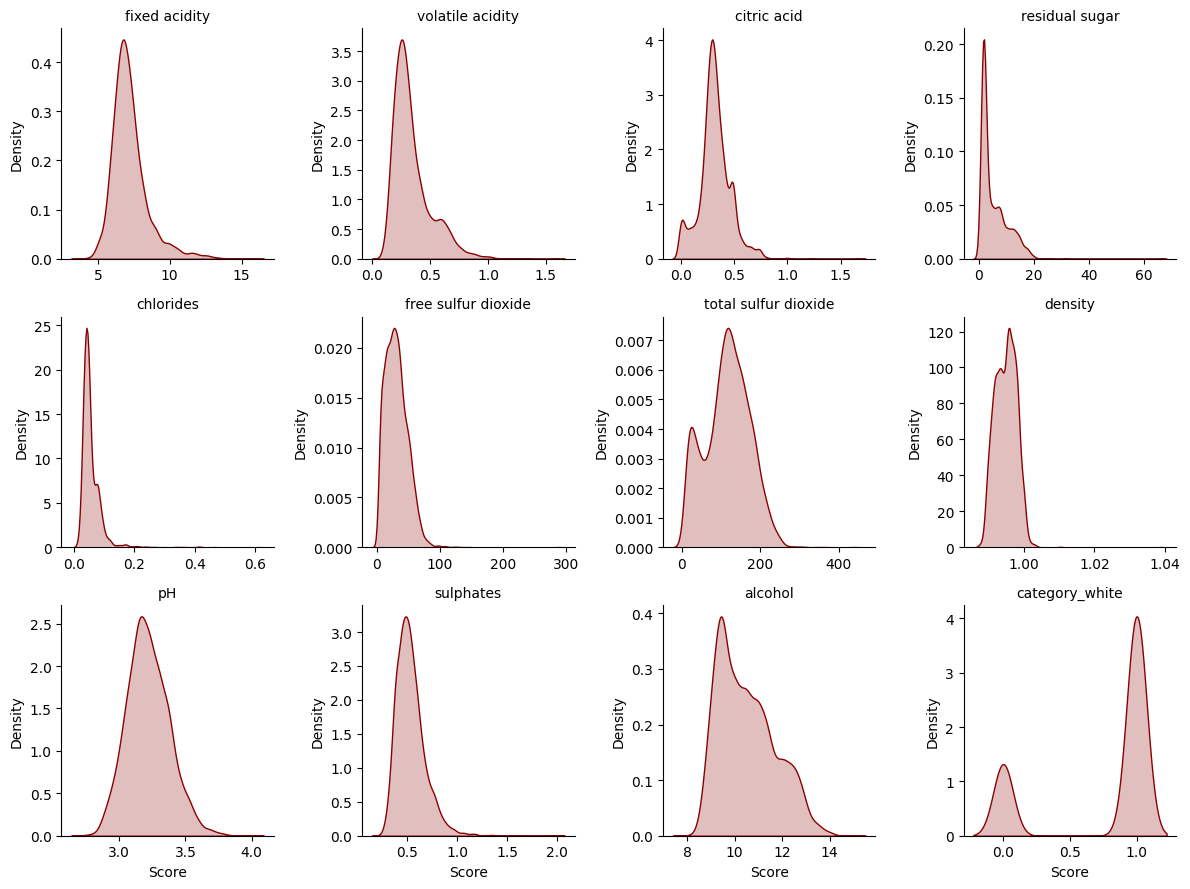

In [103]:
df_long = df.melt(id_vars='quality',
                   var_name='Variable',
                   value_name='Score')

g = sns.FacetGrid(df_long, col='Variable', col_wrap=4, sharex=False, sharey=False)

g.map_dataframe(
    sns.kdeplot,
    x='Score',
    fill=True,
    color='darkred')

g.set_titles('{col_name}')
g.fig.tight_layout()

plt.show()



*   Correlación



In [104]:
corr = df1.corr(numeric_only=True)
corr

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,category_white
fixed acidity,1.000000,0.219008,0.324436,-0.111981,0.298195,-0.282735,-0.329054,0.458910,-0.252700,0.299568,-0.095452,-0.486740
volatile acidity,0.219008,1.000000,-0.377981,-0.196011,0.377124,-0.352557,-0.414476,0.271296,0.261454,0.225984,-0.037640,-0.653036
citric acid,0.324436,-0.377981,1.000000,0.142451,0.038998,0.133126,0.195242,0.096154,-0.329808,0.056197,-0.010493,0.187397
residual sugar,-0.111981,-0.196011,0.142451,1.000000,-0.128940,0.402871,0.495482,0.552517,-0.267320,-0.185927,-0.359415,0.348821
chlorides,0.298195,0.377124,0.038998,-0.128940,1.000000,-0.195045,-0.279630,0.362615,0.044708,0.395593,-0.256916,-0.512678
free sulfur dioxide,-0.282735,-0.352557,0.133126,0.402871,-0.195045,1.000000,0.720934,0.025717,-0.145854,-0.188457,-0.179838,0.471644
total sulfur dioxide,-0.329054,-0.414476,0.195242,0.495482,-0.279630,0.720934,1.000000,0.032395,-0.238413,-0.275727,-0.265740,0.700357
density,0.458910,0.271296,0.096154,0.552517,0.362615,0.025717,0.032395,1.000000,0.011686,0.259478,-0.686745,-0.390645
pH,-0.252700,0.261454,-0.329808,-0.267320,0.044708,-0.145854,-0.238413,0.011686,1.000000,0.192123,0.121248,-0.329129
sulphates,0.299568,0.225984,0.056197,-0.185927,0.395593,-0.188457,-0.275727,0.259478,0.192123,1.000000,-0.003029,-0.487218


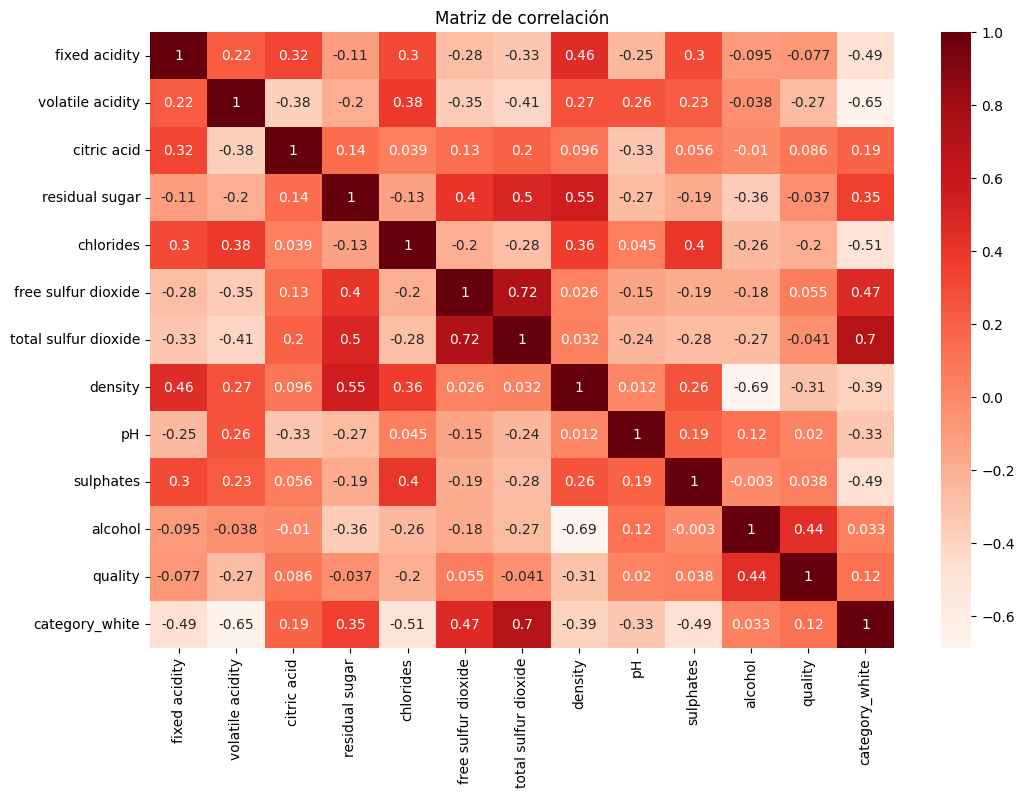

In [105]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Reds"
)

plt.title("Matriz de correlación")
plt.show()

### Análisis con la variable quality

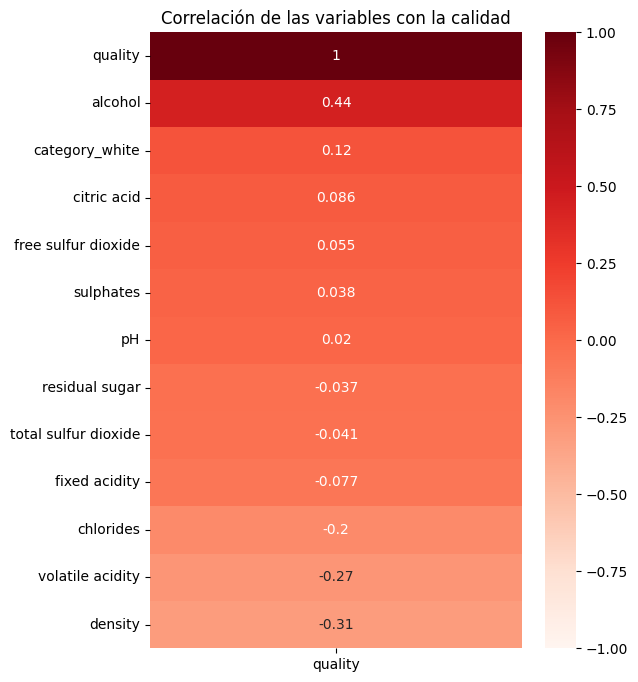

In [106]:
corr_quality = df.corr(numeric_only=True)[['quality']].sort_values(
    by='quality',
    ascending=False
)

plt.figure(figsize=(6,8))

sns.heatmap(
    corr_quality,
    annot=True,
    cmap='Reds',
    vmin=-1,
    vmax=1
)

plt.title("Correlación de las variables con la calidad")
plt.show()

In [107]:
# Calculamos la correlación de Pearson de las variables con 'quality'
corr = df.corr(numeric_only=True)["quality"].sort_values()
corr

,quality
density,-0.305858
volatile acidity,-0.265699
chlorides,-0.200666
fixed acidity,-0.076743
total sulfur dioxide,-0.041385
residual sugar,-0.036980
pH,0.019506
sulphates,0.038485
free sulfur dioxide,0.055463
citric acid,0.085532


In [108]:
# Seleccionamos las 5 variables más relacionadas sin importar el signo
top_vars = corr.abs().sort_values(ascending=False).head(5).index
top_vars

Index(['quality', 'alcohol', 'density', 'volatile acidity', 'chlorides'], dtype='object')

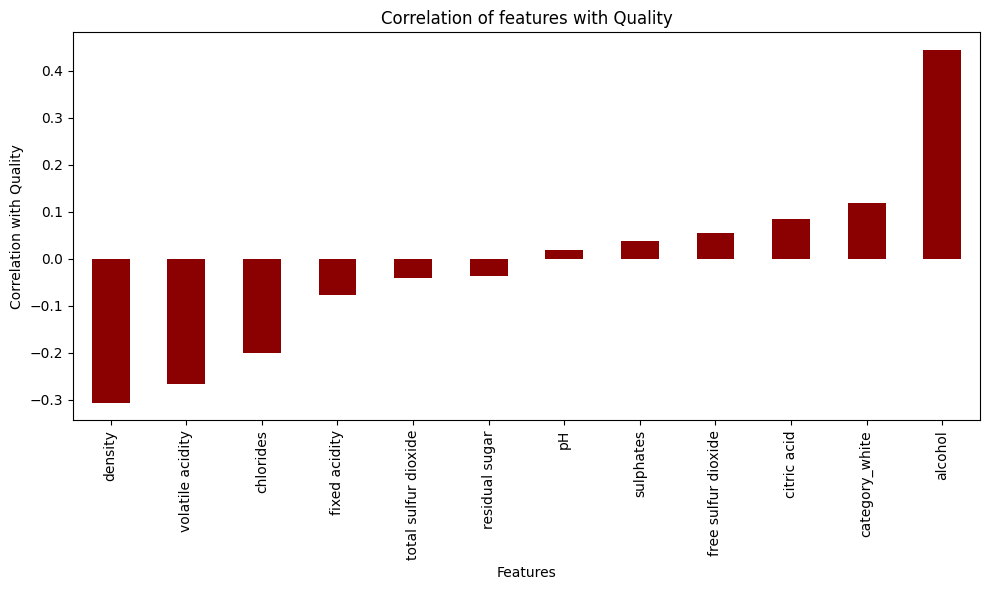

In [109]:
# Graficamos las variables mas correlacionadas
plt.figure(figsize=(10,6))

df.corr(numeric_only=True)['quality'].drop('quality') \
    .sort_values() \
    .plot(kind='bar', color='darkred')

plt.xlabel('Features')
plt.ylabel('Correlation with Quality')
plt.title('Correlation of features with Quality')

plt.tight_layout()
plt.show()

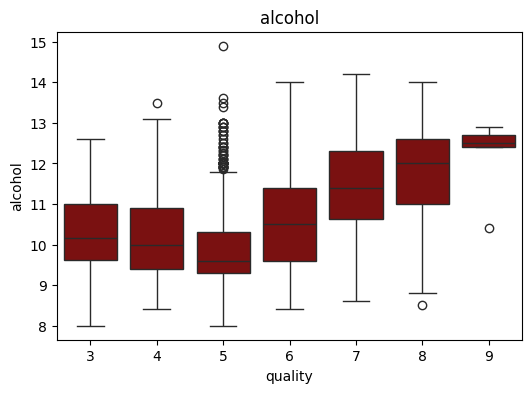

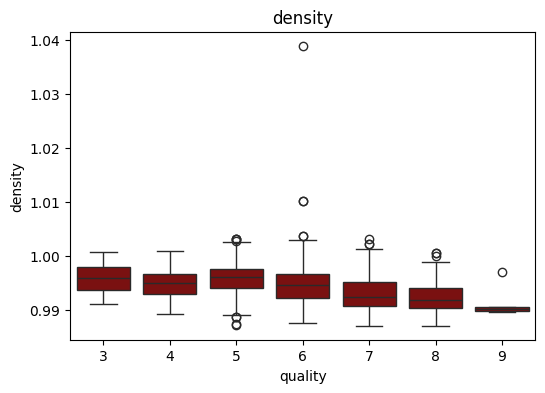

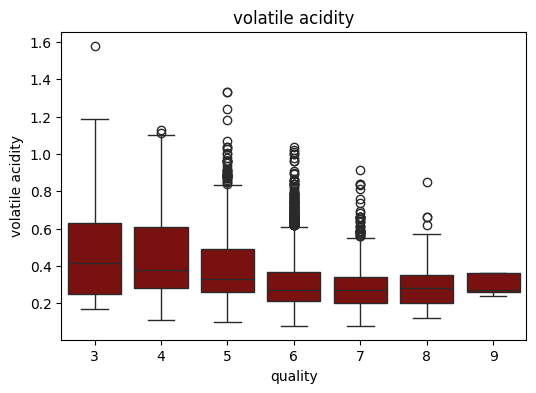

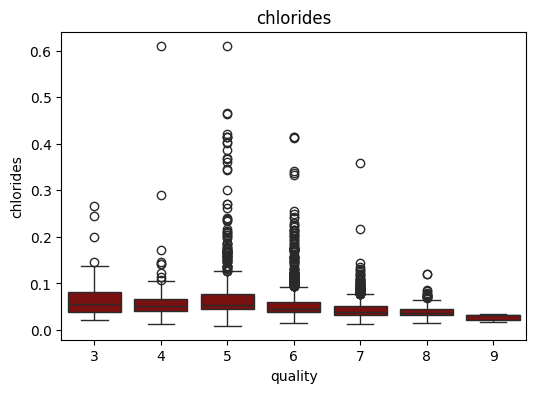

In [110]:
# Graficamos los box-plot de las variables más correlacionadas
for col in top_vars:
    if col != "quality":
        plt.figure(figsize=(6,4))
        sns.boxplot(data=df, x="quality", y=col, color="darkred")
        plt.title(col)
        plt.show()


## **Datos de Entrenamiento / Prueba**



In [111]:
X = df.drop(columns=["quality"]) # variables predictorias
y = df["quality"] # variable objetivo

print("Distribución original de clases:", np.bincount(y))

# Dividimos 75% train / 25% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state= seed, stratify=y) # la variable y esta muy desvalanceada, asi que nos aseguramos de respetar proporciones

print("Distribución en train:", np.bincount(y_train))
print("Distribución en test :", np.bincount(y_test))

Distribución original de clases: [   0    0    0   30  216 2138 2836 1079  193    5]
Distribución en train: [   0    0    0   22  162 1603 2127  809  145    4]
Distribución en test : [  0   0   0   8  54 535 709 270  48   1]


#    **Regresión:** Modelos Lineales Generalizados (GLM).

---



* #    **Regresión Lineal (baseline)**

In [112]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model = Pipeline([
    ('scaler', StandardScaler()), # Normalizamos con media 0 y desviación 1.
    ('lr', LinearRegression())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
mae_lr = mean_absolute_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred)

n = X_test.shape[0] # Número de observaciones en testt
p = X_test.shape[1]  # Número de variables predictoras

sigma2 = np.var(y_test - y_pred) # Varianza de los residuos
cp = mse_lr + 2 * sigma2 * p / n


print(f"MAE: {mae_lr:.4f}")
print(f"MSE: {mse_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R2: {r2_lr:.4f}")
print(f"Mallow's Cp: {cp:.4f}")

MAE: 0.5809
MSE: 0.5444
RMSE: 0.7378
R2: 0.2863
Mallow's Cp: 0.5524


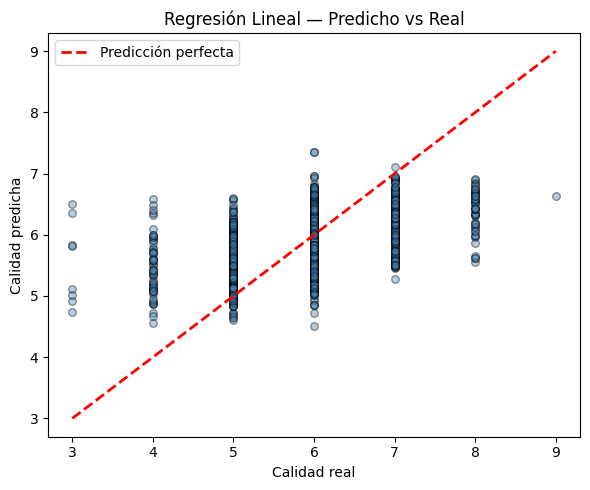

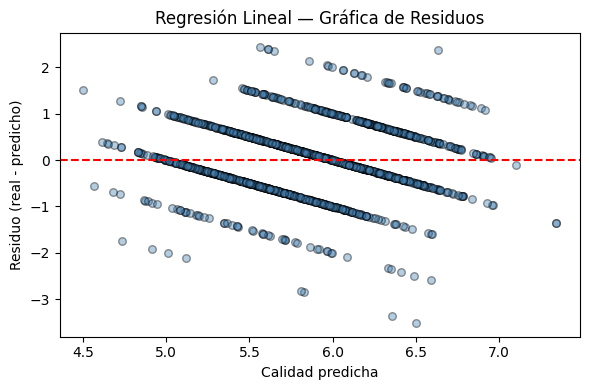

In [113]:
y_pred_lr = model.predict(X_test)
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.4, color='steelblue', edgecolors='k', s=30)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Predicción perfecta')
plt.xlabel('Calidad real')
plt.ylabel('Calidad predicha')
plt.title('Regresión Lineal — Predicho vs Real')
plt.legend()
plt.tight_layout()
plt.show()

residuos_lr = y_test - y_pred_lr

plt.figure(figsize=(6, 4))
plt.scatter(y_pred_lr, residuos_lr, alpha=0.4, color='steelblue', edgecolors='k', s=30)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Calidad predicha')
plt.ylabel('Residuo (real - predicho)')
plt.title('Regresión Lineal — Gráfica de Residuos')
plt.tight_layout()
plt.show()

El modelo de regresión lineal obtuvo un MAE promedio de 0.5809, lo que indica que la predicción se desvía menos de una unidad de calidad en promedio.

* #    **LASSO (L1)**

Fitting 10 folds for each of 6 candidates, totalling 60 fits

LASSO

Mejores hiperparámetros Lasso: {'model__alpha': 0.001}
Mejor MAE CV: 0.5676
MAE: 0.5809
MSE: 0.5442
RMSE: 0.7377
R2: 0.2865


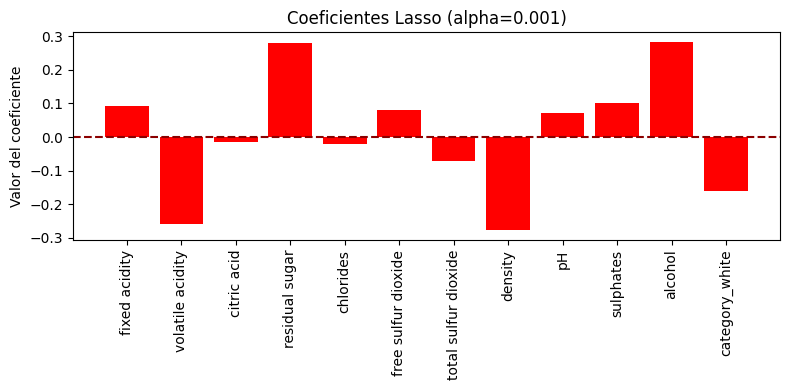


Variables eliminadas por Lasso (coeficientes en 0): []


In [114]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# Hiperparámetros para Lasso
param_grid_lasso = {
    'model__alpha': [ 0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
}

# Construimos el Pipeline para Lasso
pipe_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(random_state= seed, max_iter=2000)) # Se aumenta max_iter por convergencia
])

# Configuramos GridSearchCV
grid_lasso = GridSearchCV(
    estimator=pipe_lasso,
    param_grid=param_grid_lasso,
    cv=10,                             # dividimos train en 10 partes
    scoring='neg_mean_absolute_error',
    verbose=1
)

# Ajustamos el grid
grid_lasso.fit(X_train, y_train)

best_lasso = grid_lasso.best_estimator_

pred_lasso = best_lasso.predict(X_test)

mae_lasso = mean_absolute_error(y_test, pred_lasso)
mse_lasso = mean_squared_error(y_test, pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, pred_lasso))
r2_lasso = r2_score(y_test, pred_lasso)

print("\nLASSO")
print("\nMejores hiperparámetros Lasso:", grid_lasso.best_params_)
print(f"Mejor MAE CV: {-grid_lasso.best_score_:.4f}")
print(f"MAE: {mae_lasso:.4f}")
print(f"MSE: {mse_lasso:.4f}")
print(f"RMSE: {rmse_lasso:.4f}")
print(f"R2: {r2_lasso:.4f}")



# Coeficientes del mejor modelo encontrado por GridSearch
lasso_best = grid_lasso.best_estimator_.named_steps['model']

plt.figure(figsize=(8, 4))
plt.bar(X.columns, lasso_best.coef_, color='red')
plt.xticks(rotation=90)
plt.title(f"Coeficientes Lasso (alpha={grid_lasso.best_params_['model__alpha']})")
plt.axhline(0, color='darkred', linestyle='--')
plt.ylabel("Valor del coeficiente")
plt.tight_layout()
plt.show()

coeficientes_lasso = pd.Series(lasso_best.coef_, index=X.columns)
variables_eliminadas = coeficientes_lasso[coeficientes_lasso == 0].index.tolist()
print("\nVariables eliminadas por Lasso (coeficientes en 0):", variables_eliminadas)

GridSearchCV seleccionó **alpha=0.001 con MAE CV de 0.5676**, prácticamente idéntico al baseline lineal (diferencia de 0.0002).
Lasso confirma que todas las variables fisicoquímicas aportan información independiente: no existe un subconjunto pequeño que explique la calidad del vino sin pérdida significativa de precisión.

In [115]:
resultados_alpha = []

for a in [0.0001, 0.001, 0.01, 0.1, 1.0]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=a, max_iter=2000))
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    coefs = pipe.named_steps['model'].coef_


    resultados_alpha.append({
        'Alpha': a,
        'Variables activas': np.sum(coefs != 0),
        'MAE': mean_absolute_error(y_test, pred),
        'MSE': mean_squared_error(y_test, pred),
        'RMSE': np.sqrt(mse_lr),
        'R²': r2_score(y_test, pred)
    })

df_alpha = pd.DataFrame(resultados_alpha)
print(df_alpha.to_string(index=False))

 Alpha  Variables activas      MAE      MSE     RMSE        R²
0.0001                 12 0.580921 0.544330 0.737804  0.286291
0.0010                 12 0.580907 0.544188 0.737804  0.286477
0.0100                 11 0.582660 0.547306 0.737804  0.282388
0.1000                  2 0.607319 0.586377 0.737804  0.231160
1.0000                  0 0.685554 0.762683 0.737804 -0.000007



* #    **Ridge (L2)**







In [116]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

param_grid_ridge = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])


grid_ridge = GridSearchCV(
    estimator=pipe_ridge,
    param_grid=param_grid_ridge,
    cv=10,
    scoring='neg_mean_absolute_error',
    verbose=1
)

# Ajustamos el grid
grid_ridge.fit(X_train, y_train)


best_ridge = grid_ridge.best_estimator_
pred_ridge = best_ridge.predict(X_test)

mae_ridge = mean_absolute_error(y_test, pred_ridge)
mse_ridge = mean_squared_error(y_test, pred)
rmse_ridge = np.sqrt(mean_squared_error(y_test, pred_ridge))
r2_ridge = r2_score(y_test, pred_ridge)

print("\nRIDGE")
print("\nMejores hiperparámetros Ridge:", grid_ridge.best_params_)
print(f"Mejor MAE CV: {-grid_ridge.best_score_:.4f}")
print(f"MAE: {mae_ridge:.4f}")
print(f"MSE: {mse_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.4f}")
print(f"R2: {r2_ridge:.4f}")

Fitting 10 folds for each of 5 candidates, totalling 50 fits

RIDGE

Mejores hiperparámetros Ridge: {'model__alpha': 0.01}
Mejor MAE CV: 0.5673
MAE: 0.5809
MSE: 0.7627
RMSE: 0.7378
R2: 0.2863


**Comparativa: Regresión Lineal - Lasso - Ridge**

In [117]:
resumen_lineales = pd.DataFrame({
    'Modelo':      ['Regresión Lineal', 'Lasso (alpha=0.001)', 'Ridge (alpha=0.01)'],
    'MAE CV':      [0.5809,             0.5676,                0.5673],
    'MSE Test':    [0.5444,             0.5442,                0.7627],
    'RMSE Test':   [0.7378,             0.7377,                0.7327],
    'R² Test':     [0.2863,             0.2865,                0.2863],
    'Vars activas':[11,                 11,                    11],
})
print(resumen_lineales.to_string(index=False))

             Modelo  MAE CV  MSE Test  RMSE Test  R² Test  Vars activas
   Regresión Lineal  0.5809    0.5444     0.7378   0.2863            11
Lasso (alpha=0.001)  0.5676    0.5442     0.7377   0.2865            11
 Ridge (alpha=0.01)  0.5673    0.7627     0.7327   0.2863            11


Los tres modelos lineales son estadísticamente equivalentes.
La regularización L1 y L2 no aporta mejora de predicción en este dataset, descartando sobreajuste y multicolinealidad como fuentes de error.
El límite MAE≈0.509 por que la relación entre variables fisicoquímicas y calidad tiene  componentes no lineales que un modelo lineal no puede capturar.


#    **Modelos de Ensamble y Redes**


* #    **Random Forest**

Fitting 10 folds for each of 24 candidates, totalling 240 fits
RANDOM FOREST
Mejores hiperparámetros: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_split': 2, 'model__n_estimators': 200}
Mejor MAE CV:  0.4459
MAE:      0.4325
MSE:      0.3603
RMSE:     0.6002
R²:       0.5276

OOB R² (estimación sin test set): 0.5120
→ Si OOB R² ≈ R² Test, el modelo generaliza correctamente sin sobreajuste.


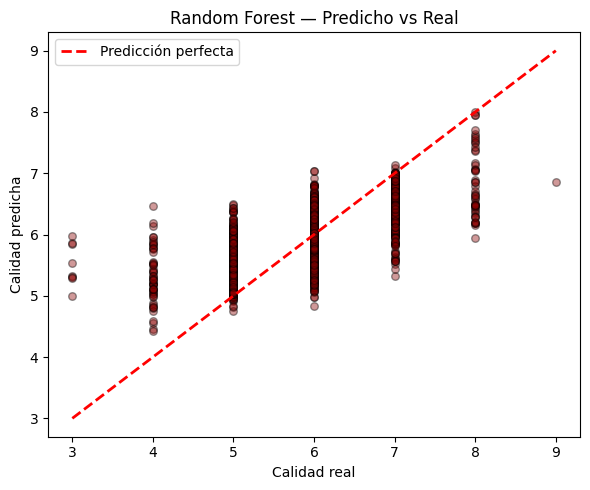


Importancia de variables — Random Forest:
                      MDI (nativa)  Permutación
alcohol                     0.1768       0.3081
volatile acidity            0.1126       0.1605
density                     0.1105       0.0997
free sulfur dioxide         0.0846       0.1074
chlorides                   0.0798       0.0674
total sulfur dioxide        0.0776       0.0645
residual sugar              0.0750       0.0524
sulphates                   0.0746       0.0654
citric acid                 0.0718       0.0620
pH                          0.0694       0.0392
fixed acidity               0.0632       0.0331
category_white              0.0041       0.0052


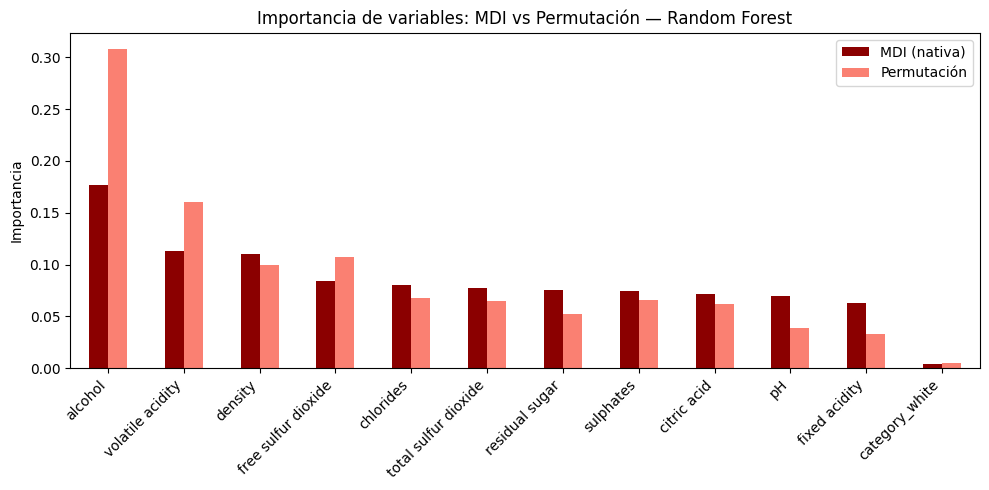

In [118]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

param_grid_rf = {
    'model__n_estimators':      [100, 200],
    'model__max_depth':         [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__max_features':      ['sqrt', 0.5]  # feature randomness clave del RF
}

pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=seed, oob_score=False))
    # oob_score=False en el pipeline porque OOB lo calculamos aparte abajo
])

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=10,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
pred_rf = grid_rf.best_estimator_.predict(X_test)

mae_rf  = mean_absolute_error(y_test, pred_rf)
mse_rf = mean_squared_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf   = r2_score(y_test, pred_rf)

print("RANDOM FOREST")
print("Mejores hiperparámetros:", grid_rf.best_params_)
print(f"Mejor MAE CV:  {-grid_rf.best_score_:.4f}")
print(f"MAE:      {mae_rf:.4f}")
print(f"MSE:      {mse_rf:.4f}")
print(f"RMSE:     {rmse_rf:.4f}")
print(f"R²:       {r2_rf:.4f}")

# OOB Score (estimación honesta sin usar X_test)
# Entrenamos un RF aparte con los mejores hiperparámetros + oob_score=True
best_params_rf = grid_rf.best_params_
rf_oob = RandomForestRegressor(
    n_estimators      = best_params_rf['model__n_estimators'],
    max_depth         = best_params_rf['model__max_depth'],
    min_samples_split = best_params_rf['model__min_samples_split'],
    max_features      = best_params_rf['model__max_features'],
    oob_score         = True,
    random_state      = seed
)
# OOB necesita datos sin escalar para este cálculo directo
# (RF no necesita escalado, el Pipeline lo incluye por consistencia global)
from sklearn.preprocessing import StandardScaler as SS
scaler_oob = SS()
X_train_sc = scaler_oob.fit_transform(X_train)
rf_oob.fit(X_train_sc, y_train)
print(f"\nOOB R² (estimación sin test set): {rf_oob.oob_score_:.4f}")
print("→ Si OOB R² ≈ R² Test, el modelo generaliza correctamente sin sobreajuste.")


# Predicho vs Real
plt.figure(figsize=(6, 5))
plt.scatter(y_test, pred_rf, alpha=0.4, color='darkred', edgecolors='k', s=30)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Predicción perfecta')
plt.xlabel('Calidad real')
plt.ylabel('Calidad predicha')
plt.title('Random Forest — Predicho vs Real')
plt.legend()
plt.tight_layout()
plt.show()

# ── Importancia de variables: MDI vs Permutación
rf_best_model = grid_rf.best_estimator_.named_steps['model']

imp_mdi = pd.Series(rf_best_model.feature_importances_, index=X.columns)

perm = permutation_importance(
    grid_rf.best_estimator_, X_test, y_test,
    n_repeats=10, random_state=seed, n_jobs=-1)
imp_perm = pd.Series(perm.importances_mean, index=X.columns)

df_imp_rf = pd.DataFrame({
    'MDI (nativa)': imp_mdi,
    'Permutación':  imp_perm
}).sort_values('MDI (nativa)', ascending=False)

print("\nImportancia de variables — Random Forest:")
print(df_imp_rf.round(4))

df_imp_rf.plot(kind='bar', figsize=(10, 5), color=['darkred', 'salmon'])
plt.title('Importancia de variables: MDI vs Permutación — Random Forest')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



Fitting 10 folds for each of 12 candidates, totalling 120 fits
RANDOM FOREST
Mejores hiperparámetros: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Mejor MAE CV:  0.4495
MAE:      0.4354
MSE:      0.3707
RMSE:     0.6088
R²:       0.5140


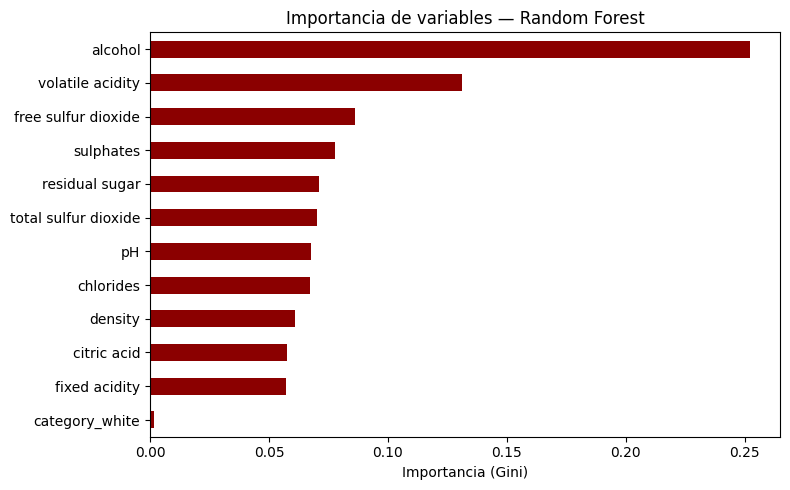

In [119]:
from sklearn.ensemble import RandomForestRegressor

param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth':    [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=seed))
])

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=10,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
pred_rf = grid_rf.best_estimator_.predict(X_test)

mae_rf  = mean_absolute_error(y_test, pred_rf)
mse_rf = mean_squared_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf   = r2_score(y_test, pred_rf)

print("RANDOM FOREST")
print("Mejores hiperparámetros:", grid_rf.best_params_)
print(f"Mejor MAE CV:  {-grid_rf.best_score_:.4f}")
print(f"MAE:      {mae_rf:.4f}")
print(f"MSE:      {mse_rf:.4f}")
print(f"RMSE:     {rmse_rf:.4f}")
print(f"R²:       {r2_rf:.4f}")

# Importancia de variables
rf_best = grid_rf.best_estimator_.named_steps['model']
importancias_rf = pd.Series(rf_best.feature_importances_, index=X.columns)
importancias_rf = importancias_rf.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importancias_rf.plot(kind='barh', color='darkred')
plt.title('Importancia de variables — Random Forest')
plt.xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

* #    **AdaBoost**

Fitting 10 folds for each of 18 candidates, totalling 180 fits
ADABOOST
Mejores hiperparámetros: {'model__estimator': DecisionTreeRegressor(max_depth=5), 'model__learning_rate': 0.1, 'model__n_estimators': 200}
Mejor MAE CV:  0.5570
MAE:      0.5625
MSE:      0.4978
RMSE:     0.7055
R²:       0.3473


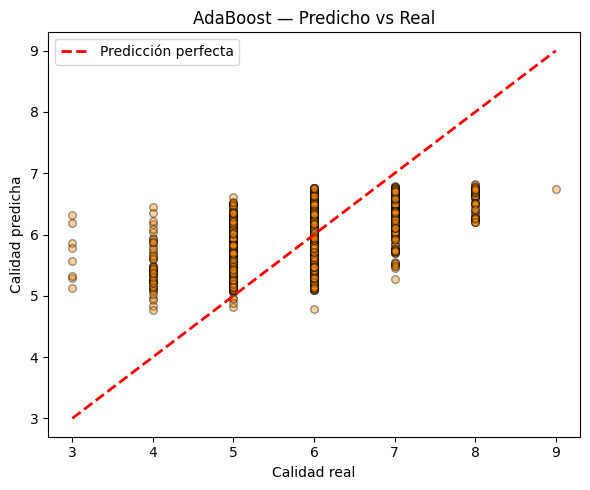

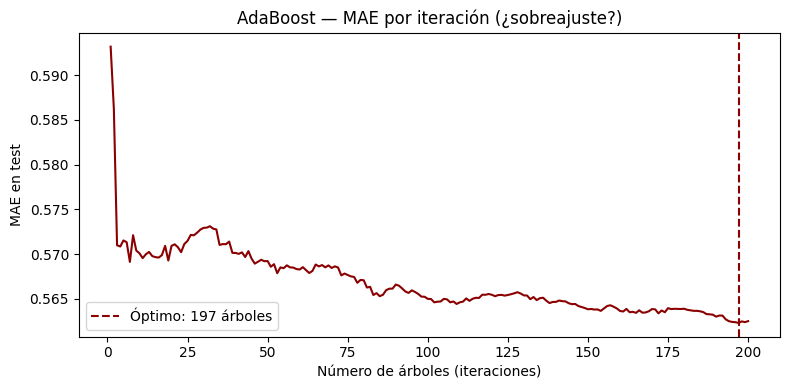

Número óptimo de árboles según curva: 197


In [120]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

param_grid_ada = {
    'model__n_estimators':  [50, 100, 200],
    'model__learning_rate': [0.01, 0.1, 0.5],
    'model__estimator':     [
        DecisionTreeRegressor(max_depth=3),
        DecisionTreeRegressor(max_depth=5)
    ]
}

pipe_ada = Pipeline([
    ('scaler', StandardScaler()),
    ('model', AdaBoostRegressor(random_state=seed))
])

grid_ada = GridSearchCV(
    estimator=pipe_ada,
    param_grid=param_grid_ada,
    cv=10,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1
)

grid_ada.fit(X_train, y_train)
pred_ada = grid_ada.best_estimator_.predict(X_test)

mae_ada  = mean_absolute_error(y_test, pred_ada)
mse_ada = mean_squared_error(y_test, pred_ada)
rmse_ada = np.sqrt(mean_squared_error(y_test, pred_ada))
r2_ada   = r2_score(y_test, pred_ada)

print("ADABOOST")
print("Mejores hiperparámetros:", grid_ada.best_params_)
print(f"Mejor MAE CV:  {-grid_ada.best_score_:.4f}")
print(f"MAE:      {mae_ada:.4f}")
print(f"MSE:      {mse_ada:.4f}")
print(f"RMSE:     {rmse_ada:.4f}")
print(f"R²:       {r2_ada:.4f}")

# 1. Predicho vs Real
plt.figure(figsize=(6, 5))
plt.scatter(y_test, pred_ada, alpha=0.4, color='darkorange', edgecolors='k', s=30)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Predicción perfecta')
plt.xlabel('Calidad real')
plt.ylabel('Calidad predicha')
plt.title('AdaBoost — Predicho vs Real')
plt.legend()
plt.tight_layout()
plt.show()

#  Curva de error por número de iteraciones
# Muestra si más árboles ayudan o sobreajustan
ada_best_model = grid_ada.best_estimator_.named_steps['model']

errores_ada = []
for pred_iteracion in ada_best_model.staged_predict(
        grid_ada.best_estimator_.named_steps['scaler'].transform(X_test)):
    errores_ada.append(mean_absolute_error(y_test, pred_iteracion))

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(errores_ada) + 1), errores_ada, color='darkred')
plt.xlabel('Número de árboles (iteraciones)')
plt.ylabel('MAE en test')
plt.title('AdaBoost — MAE por iteración (¿sobreajuste?)')
plt.axvline(np.argmin(errores_ada) + 1, color='darkred', linestyle='--',
            label=f'Óptimo: {np.argmin(errores_ada)+1} árboles')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Número óptimo de árboles según curva: {np.argmin(errores_ada)+1}")


* #    **XGBoost**

XGBOOST
Árboles óptimos (early stopping): 393
MAE:  0.4845
MSE:  0.4094
RMSE: 0.6399
R²:   0.4632


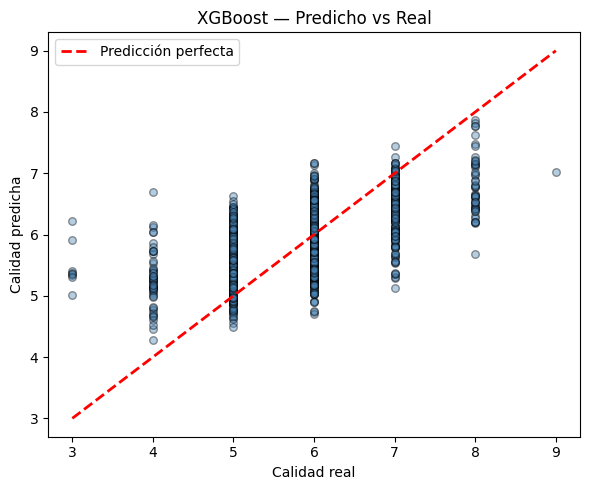

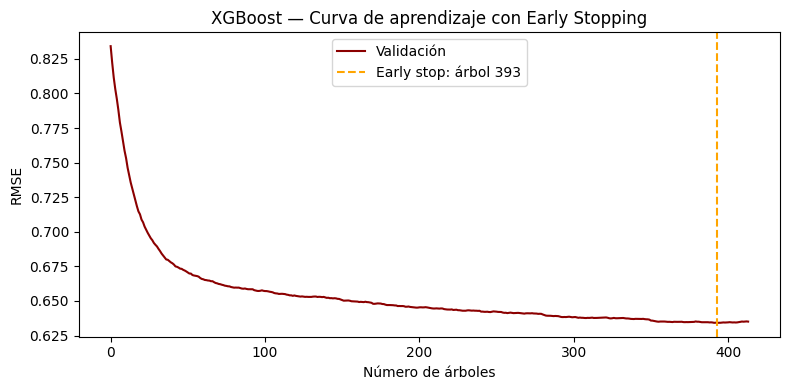

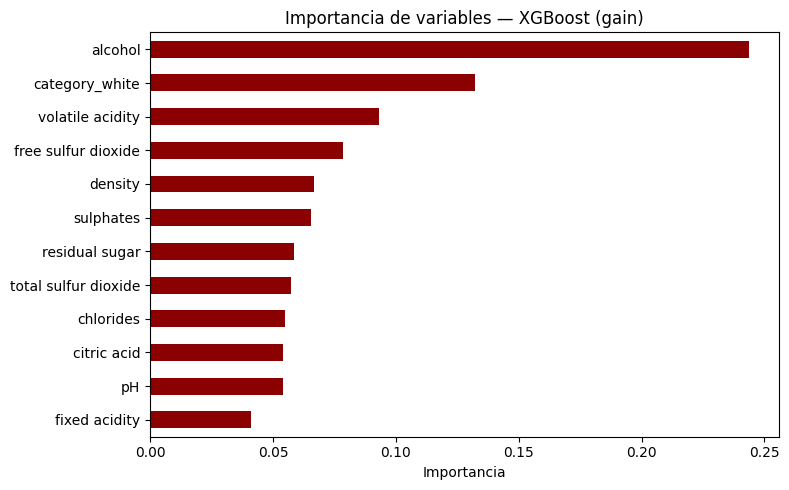

In [121]:
from xgboost import XGBRegressor

# Separamos una porción de train para early stopping (no tocamos X_test)
X_tr_xgb, X_val_xgb, y_tr_xgb, y_val_xgb = train_test_split(
    X_train, y_train, test_size=0.15, random_state=seed)

# Escalado manual porque XGBoost con early stopping no acepta Pipeline directo
scaler_xgb    = StandardScaler()
X_tr_xgb_sc   = scaler_xgb.fit_transform(X_tr_xgb)
X_val_xgb_sc  = scaler_xgb.transform(X_val_xgb)
X_test_xgb_sc = scaler_xgb.transform(X_test)

xgb_model = XGBRegressor(
    n_estimators          = 1000,
    learning_rate         = 0.05,
    max_depth             = 5,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    random_state          = seed,
    verbosity             = 0,
    early_stopping_rounds = 20
)

xgb_model.fit(
    X_tr_xgb_sc, y_tr_xgb,
    eval_set=[(X_val_xgb_sc, y_val_xgb)],
    verbose=False
)

pred_xgb = xgb_model.predict(X_test_xgb_sc)

mae_xgb  = mean_absolute_error(y_test, pred_xgb)
mse_xgb  = mean_squared_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb   = r2_score(y_test, pred_xgb)

print("XGBOOST")
print(f"Árboles óptimos (early stopping): {xgb_model.best_iteration}")
print(f"MAE:  {mae_xgb:.4f}")
print(f"MSE:  {mse_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R²:   {r2_xgb:.4f}")

#  Predicho vs Real
plt.figure(figsize=(6, 5))
plt.scatter(y_test, pred_xgb, alpha=0.4, color='steelblue', edgecolors='k', s=30)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Predicción perfecta')
plt.xlabel('Calidad real')
plt.ylabel('Calidad predicha')
plt.title('XGBoost — Predicho vs Real')
plt.legend()
plt.tight_layout()
plt.show()

#  Curva de aprendizaje con Early Stopping
resultados_xgb = xgb_model.evals_result()

plt.figure(figsize=(8, 4))
plt.plot(resultados_xgb['validation_0']['rmse'], color='darkred', label='Validación')
plt.axvline(xgb_model.best_iteration, color='orange', linestyle='--',
            label=f'Early stop: árbol {xgb_model.best_iteration}')
plt.xlabel('Número de árboles')
plt.ylabel('RMSE')
plt.title('XGBoost — Curva de aprendizaje con Early Stopping')
plt.legend()
plt.tight_layout()
plt.show()

#  Importancia de variables
imp_xgb = pd.Series(xgb_model.feature_importances_, index=X.columns)
imp_xgb = imp_xgb.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
imp_xgb.plot(kind='barh', color='darkred')
plt.title('Importancia de variables — XGBoost (gain)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()


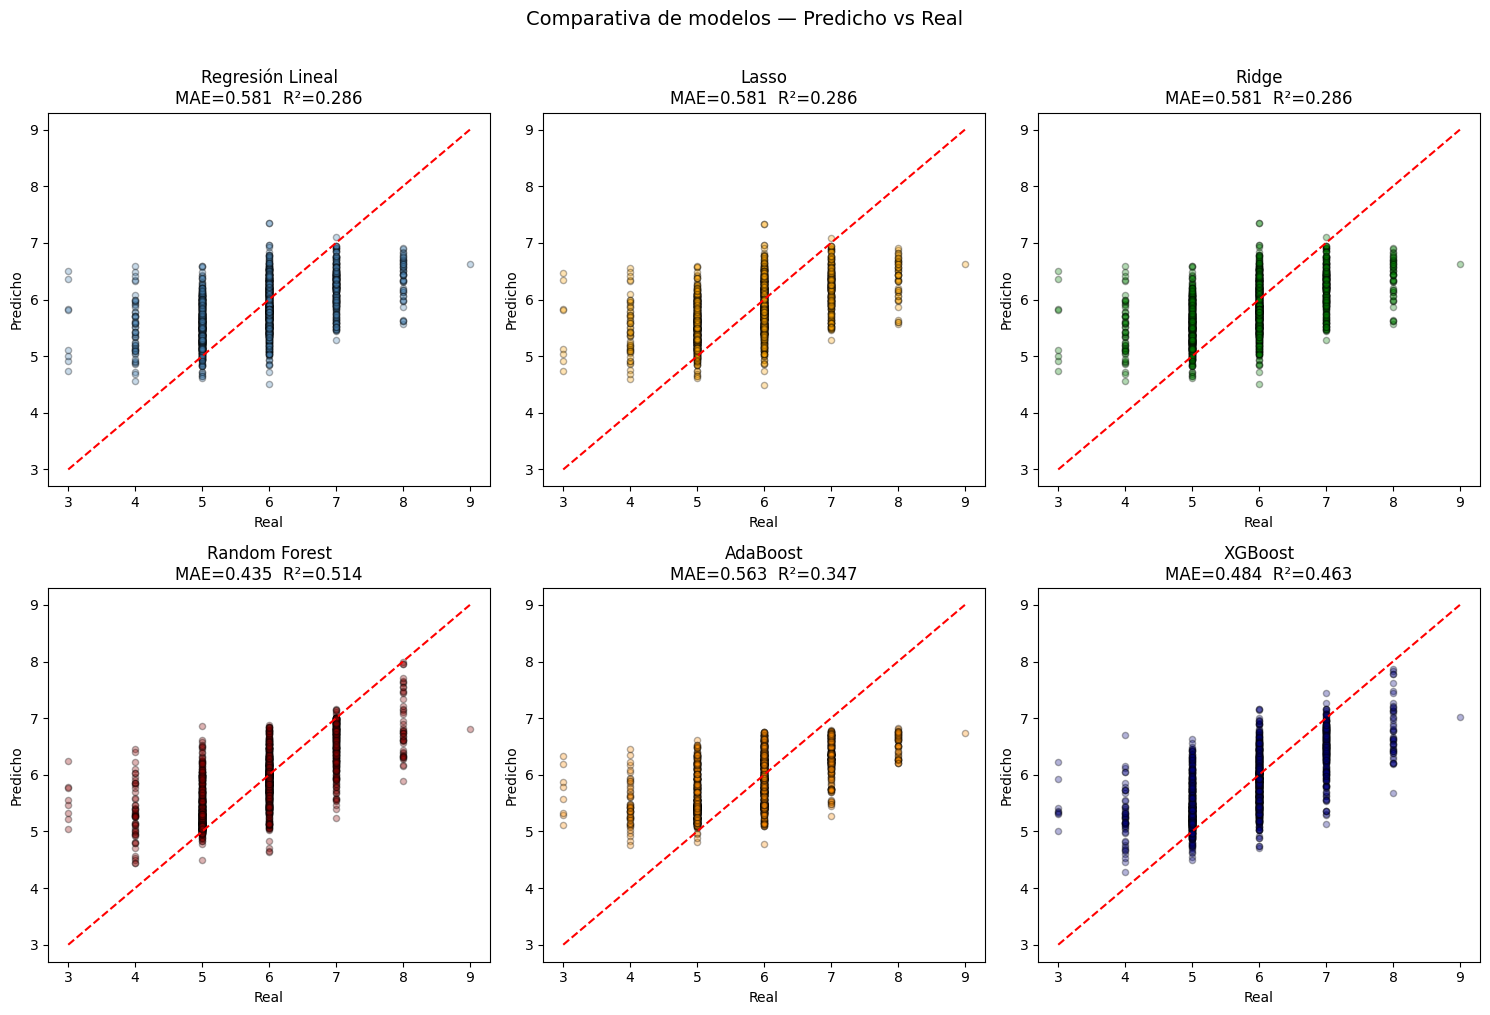

In [122]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
modelos = {
    'Regresión Lineal': (y_pred_lr,  'steelblue'),
    'Lasso':            (pred_lasso, 'orange'),
    'Ridge':            (pred_ridge, 'green'),
    'Random Forest':    (pred_rf,    'darkred'),
    'AdaBoost':         (pred_ada,   'darkorange'),
    'XGBoost':          (pred_xgb,   'navy'),
}

for ax, (nombre, (pred, color)) in zip(axes.flat, modelos.items()):
    ax.scatter(y_test, pred, alpha=0.3, color=color, edgecolors='k', s=20)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', linewidth=1.5)
    mae = mean_absolute_error(y_test, pred)
    r2  = r2_score(y_test, pred)
    ax.set_title(f'{nombre}\nMAE={mae:.3f}  R²={r2:.3f}')
    ax.set_xlabel('Real')
    ax.set_ylabel('Predicho')

plt.suptitle('Comparativa de modelos — Predicho vs Real', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


* #    **Multilayer Perceptron (MLP)**

Fitting 10 folds for each of 36 candidates, totalling 360 fits
MLP — PERCEPTRÓN MULTICAPA
Mejores hiperparámetros: {'model__activation': 'relu', 'model__alpha': 0.001, 'model__hidden_layer_sizes': (128, 64, 32), 'model__learning_rate_init': 0.001}
Mejor MAE CV:  0.5323
MAE:           0.5267
MSE:           0.4639
RMSE:          0.6811
R²:            0.3918


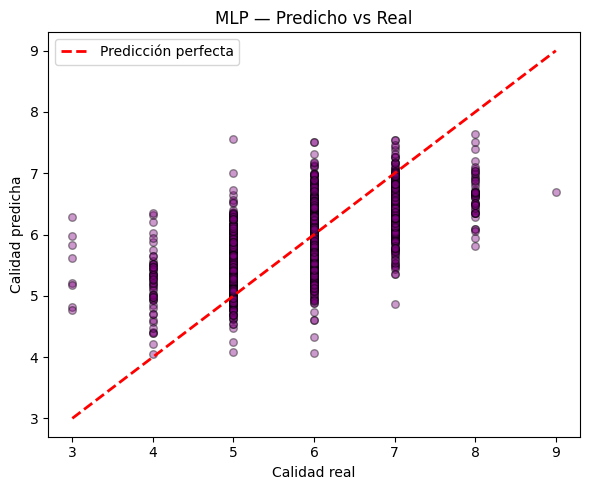

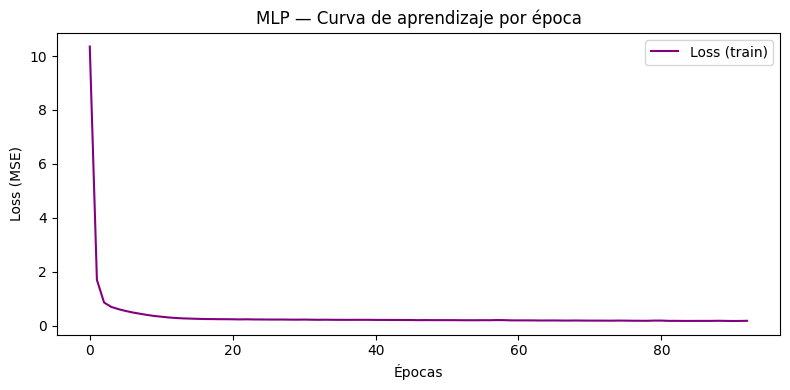

Épocas entrenadas:       93
Loss final (train):      0.1759
Mejor score validación:  0.3823

Arquitectura seleccionada:
  Entrada:       12 neuronas (una por variable)
  Capas ocultas: (128, 64, 32) con activación relu
  Salida:        1 neurona (calidad del vino)
  Regularización L2 (alpha): 0.001



In [123]:
from sklearn.neural_network import MLPRegressor

param_grid_mlp = {
    'model__hidden_layer_sizes': [
        (64,),          # 1 capa oculta, 64 neuronas
        (64, 32),       # 2 capas ocultas
        (128, 64, 32),  # 3 capas ocultas
    ],
    'model__activation':    ['relu', 'tanh'],
    'model__alpha':         [0.0001, 0.001, 0.01],  # regularización L2
    'model__learning_rate_init': [0.001, 0.01],
}

pipe_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(
        max_iter     = 1000,
        random_state = seed,
        early_stopping   = True,
        validation_fraction = 0.1, # 10% de train para monitorear
        n_iter_no_change = 15
    ))
])

grid_mlp = GridSearchCV(
    estimator  = pipe_mlp,
    param_grid = param_grid_mlp,
    cv         = 10,
    scoring    = 'neg_mean_absolute_error',
    verbose    = 1,
    n_jobs     = -1
)

grid_mlp.fit(X_train, y_train)
pred_mlp = grid_mlp.best_estimator_.predict(X_test)

mae_mlp  = mean_absolute_error(y_test, pred_mlp)
mse_mlp  = mean_squared_error(y_test, pred_mlp)
rmse_mlp = np.sqrt(mse_mlp)
r2_mlp   = r2_score(y_test, pred_mlp)

print("MLP — PERCEPTRÓN MULTICAPA")
print("Mejores hiperparámetros:", grid_mlp.best_params_)
print(f"Mejor MAE CV:  {-grid_mlp.best_score_:.4f}")
print(f"MAE:           {mae_mlp:.4f}")
print(f"MSE:           {mse_mlp:.4f}")
print(f"RMSE:          {rmse_mlp:.4f}")
print(f"R²:            {r2_mlp:.4f}")

# Predicho vs Real
plt.figure(figsize=(6, 5))
plt.scatter(y_test, pred_mlp, alpha=0.4, color='purple', edgecolors='k', s=30)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Predicción perfecta')
plt.xlabel('Calidad real')
plt.ylabel('Calidad predicha')
plt.title('MLP — Predicho vs Real')
plt.legend()
plt.tight_layout()
plt.show()

# Curva de pérdida (loss curve)
# Muestra cómo aprendió la red época por época
mlp_best = grid_mlp.best_estimator_.named_steps['model']

plt.figure(figsize=(8, 4))
plt.plot(mlp_best.loss_curve_, color='purple', label='Loss (train)')
plt.xlabel('Épocas')
plt.ylabel('Loss (MSE)')
plt.title('MLP — Curva de aprendizaje por época')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Épocas entrenadas:       {mlp_best.n_iter_}")
print(f"Loss final (train):      {mlp_best.loss_:.4f}")
print(f"Mejor score validación:  {mlp_best.best_validation_score_:.4f}")

# Arquitectura del mejor modelo
capas = grid_mlp.best_params_['model__hidden_layer_sizes']
activacion = grid_mlp.best_params_['model__activation']
alpha_mlp = grid_mlp.best_params_['model__alpha']

print(f"""
Arquitectura seleccionada:
  Entrada:       {X_train.shape[1]} neuronas (una por variable)
  Capas ocultas: {capas} con activación {activacion}
  Salida:        1 neurona (calidad del vino)
  Regularización L2 (alpha): {alpha_mlp}
""")



# **Comparación de los Modelos**

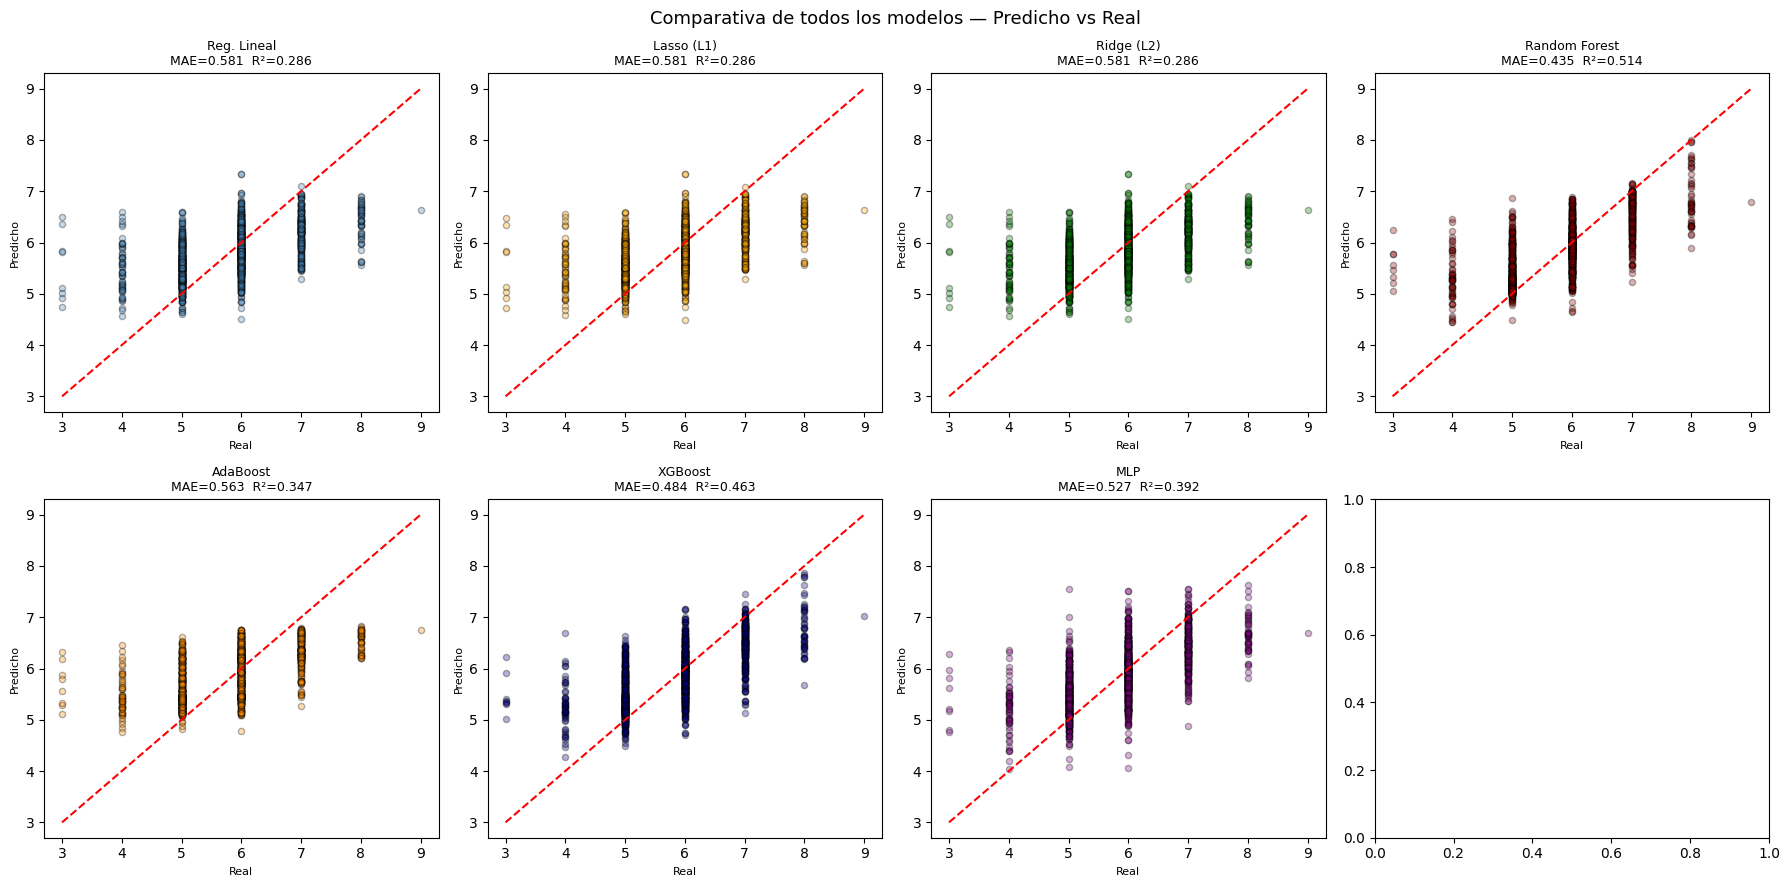

In [124]:
# Panel de predicho vs real para todos los modelos de una sola vista
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

modelos_comparativa = {
    'Reg. Lineal':    (y_pred_lr,    'steelblue'),
    'Lasso (L1)':     (pred_lasso,   'orange'),
    'Ridge (L2)':     (pred_ridge,   'green'),
    'Random Forest':  (pred_rf,      'darkred'),
    'AdaBoost':       (pred_ada,     'darkorange'),
    'XGBoost':        (pred_xgb,     'navy'),
    'MLP':            (pred_mlp,     'purple'),
}

for ax, (nombre, (pred, color)) in zip(axes.flat, modelos_comparativa.items()):
    ax.scatter(y_test, pred, alpha=0.3, color=color, edgecolors='k', s=20)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', linewidth=1.5)
    mae_i = mean_absolute_error(y_test, pred)
    r2_i  = r2_score(y_test, pred)
    ax.set_title(f'{nombre}\nMAE={mae_i:.3f}  R²={r2_i:.3f}', fontsize=9)
    ax.set_xlabel('Real', fontsize=8)
    ax.set_ylabel('Predicho', fontsize=8)

plt.suptitle('Comparativa de todos los modelos — Predicho vs Real', fontsize=13)
plt.tight_layout()
plt.show()




 TABLA COMPARATIVA FINAL 
       Modelo      MAE     RMSE       R²
Random Forest 0.435412 0.608840 0.513968
      XGBoost 0.484500 0.639868 0.463167
          MLP 0.526697 0.681089 0.391772
     AdaBoost 0.562516 0.705531 0.347335
   Lasso (L1) 0.580907 0.737691 0.286477
   Ridge (L2) 0.580924 0.737804 0.286259
  Reg. Lineal 0.580924 0.737804 0.286259

 Mejor modelo por MAE: Random Forest


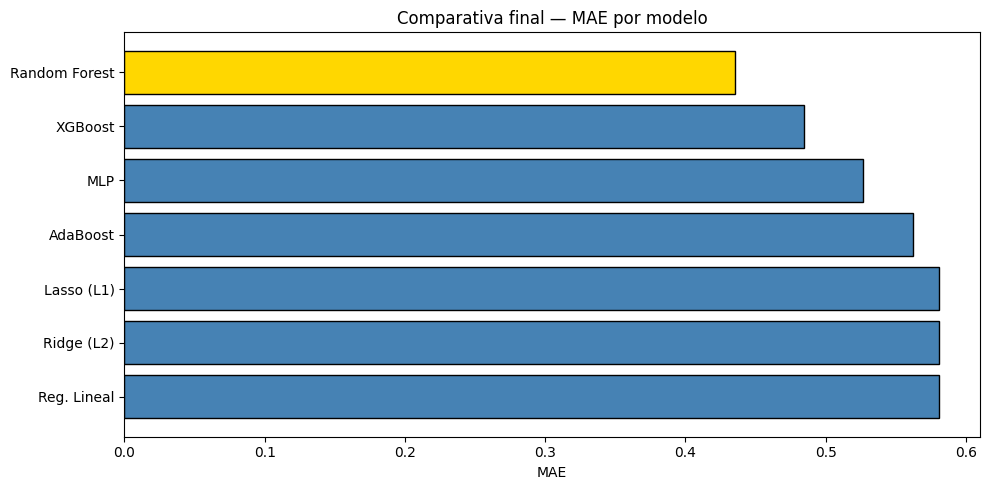

In [125]:
# Tabla resumen
resumen_final = pd.DataFrame({
    'Modelo': [
        'Reg. Lineal', 'Lasso (L1)', 'Ridge (L2)',
        'Random Forest', 'AdaBoost', 'XGBoost', 'MLP'
    ],
    'MAE':  [mae_lr,   mae_lasso,  mae_ridge,
             mae_rf,  mae_ada,  mae_xgb,  mae_mlp],
    'RMSE': [rmse_lr,  rmse_lasso, rmse_ridge,
             rmse_rf, rmse_ada, rmse_xgb, rmse_mlp],
    'R²':   [r2_lr,    r2_lasso,   r2_ridge,
             r2_rf,  r2_ada,    r2_xgb,  r2_mlp],
}).sort_values('MAE').reset_index(drop=True)

print("\n TABLA COMPARATIVA FINAL ")
print(resumen_final.to_string(index=False))
print("\n Mejor modelo por MAE:", resumen_final.iloc[0]['Modelo'])

# Gráfico de barras de MAE por modelo
plt.figure(figsize=(10, 5))
colores = ['gold' if i == 0 else 'steelblue' for i in range(len(resumen_final))]
plt.barh(resumen_final['Modelo'], resumen_final['MAE'], color=colores, edgecolor='k')
plt.xlabel('MAE')
plt.title('Comparativa final — MAE por modelo')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


4. Optimización de Funciones de Pérdida

In [126]:
from sklearn.linear_model import LinearRegression, QuantileRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

*Modelo que optimiza MSE*

In [127]:
modelo_mse = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LinearRegression())
])

modelo_mse.fit(X_train, y_train)

pred_mse = modelo_mse.predict(X_test)

*Modelo que optimiza MAE*

In [128]:
modelo_mae = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', QuantileRegressor(
        quantile=0.5,
        alpha=0,
        solver="highs"
    ))
])

modelo_mae.fit(X_train, y_train)

pred_mae = modelo_mae.predict(X_test)

*Calculamos Metricas*

In [129]:
resultados = pd.DataFrame({

    "Modelo":[
        "Optimiza MSE (Linear Regression)",
        "Optimiza MAE (Quantile Regression)"
    ],

    "MAE":[
        mean_absolute_error(y_test,pred_mse),
        mean_absolute_error(y_test,pred_mae)
    ],

    "MSE":[
        mean_squared_error(y_test,pred_mse),
        mean_squared_error(y_test,pred_mae)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test,pred_mse)),
        np.sqrt(mean_squared_error(y_test,pred_mae))
    ],

    "R²":[
        r2_score(y_test,pred_mse),
        r2_score(y_test,pred_mae)
    ]

})

print(resultados)

                               Modelo       MAE       MSE      RMSE        R²
0    Optimiza MSE (Linear Regression)  0.580924  0.544355  0.737804  0.286259
1  Optimiza MAE (Quantile Regression)  0.578257  0.546363  0.739164  0.283625


*Gráfica Predicción vs Real*

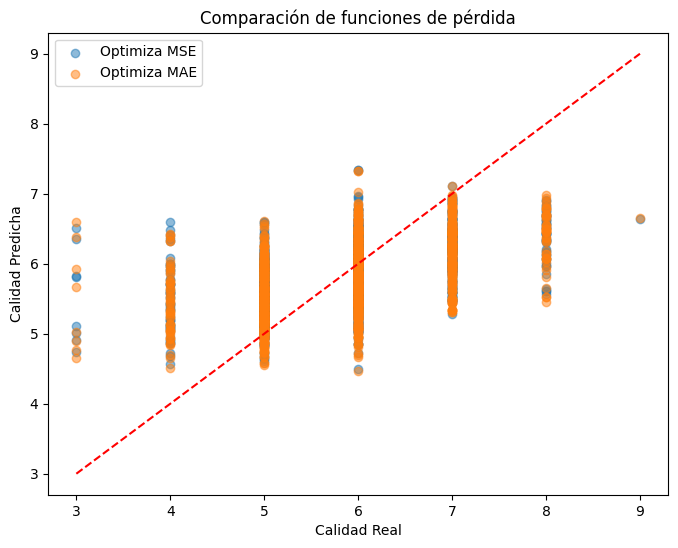

In [130]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    pred_mse,
    alpha=0.5,
    label="Optimiza MSE"
)

plt.scatter(
    y_test,
    pred_mae,
    alpha=0.5,
    label="Optimiza MAE"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Calidad Real")
plt.ylabel("Calidad Predicha")
plt.title("Comparación de funciones de pérdida")

plt.legend()

plt.show()

*Grafica de Residuos*

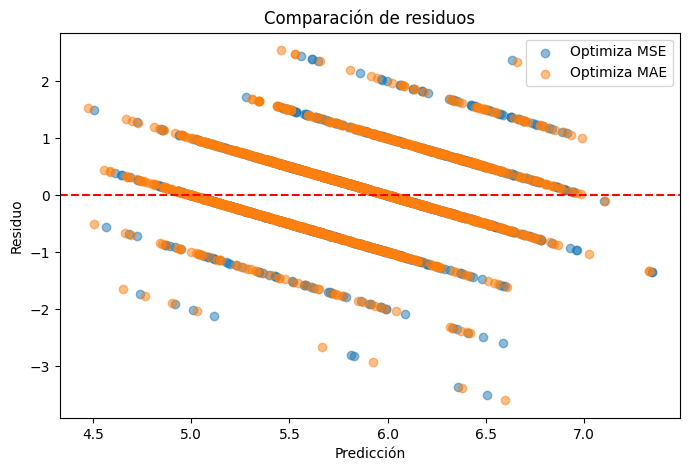

In [131]:
residuos_mse = y_test - pred_mse
residuos_mae = y_test - pred_mae

plt.figure(figsize=(8,5))

plt.scatter(
    pred_mse,
    residuos_mse,
    alpha=0.5,
    label="Optimiza MSE"
)

plt.scatter(
    pred_mae,
    residuos_mae,
    alpha=0.5,
    label="Optimiza MAE"
)

plt.axhline(0,color="red",linestyle="--")

plt.xlabel("Predicción")
plt.ylabel("Residuo")

plt.title("Comparación de residuos")

plt.legend()

plt.show()

In [132]:
print(resultados)

                               Modelo       MAE       MSE      RMSE        R²
0    Optimiza MSE (Linear Regression)  0.580924  0.544355  0.737804  0.286259
1  Optimiza MAE (Quantile Regression)  0.578257  0.546363  0.739164  0.283625
